# Building a binary classifier model with PyTorch

This notebook address following steps:
- Build a PyTorch `Dataset`/`DataLoader` pipeline  
- Build a small fully-connected neural network with PyTorch
- Build a training loop (with validation) with PyTorch  
- Draw plots: training/validation loss, accuracy, ROC curve, and confusion matrix  
- Save and load a model


In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm

# Seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)


# Data loadig and preprocessing

With `pandas` and `scikit-learn`

## Load data

### Import a local file on Google Colab

- mount your google drive so that it is binded with this notebook

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

- Download csv file from Kaggle page at this address: https://www.kaggle.com/aakash50897/churn-modellingcsv?select=Churn_Modelling.csv
- Upload it in your drive
- Explore files in left windows to find it. then right click `copy path`
- Or, use `os.listdir()` to find the path

In [3]:
# csv_path = "/content/drive/MyDrive/Benoit Perso/DSTI/cours_ann/03/datasets/Churn_Modelling.csv"
# dataset = pd.read_csv(csv_path)
# dataset.head()

### Download file from kagglehub

In [6]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("aakash50897/churn-modellingcsv")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'churn-modellingcsv' dataset.
Path to dataset files: /kaggle/input/churn-modellingcsv


In [7]:
csv_dir_path = "/root/.cache/kagglehub/datasets/aakash50897/churn-modellingcsv/versions/1"
os.listdir(csv_dir_path)

['Churn_Modelling.csv']

In [8]:
csv_path = os.path.join(csv_dir_path, os.listdir(csv_dir_path)[0])
dataset = pd.read_csv(csv_path)
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Explore dataset, create input matrix and target values


In [9]:
#column names
dataset.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [10]:
# number of rows
print(dataset.index)
print(len(dataset))

RangeIndex(start=0, stop=10000, step=1)
10000


- Not all independent variables are important for the result (such as `"RowNumber"`, `"CustomerId"`)
- We can discard them with `iloc` or `drop()`. The result is the same
- we keep labels (`"Exited"`) as a separate object

In [11]:
X = dataset.iloc[:,3:13]
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [12]:
X = dataset.drop(columns=["RowNumber", "CustomerId", "Surname", "Exited"])
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [13]:
y = dataset.loc[:, "Exited"]
y.head()

,Exited
0,1
1,0
2,1
3,0
4,0


## Data encoding :

We have to encode categorical data (such as `"Geography"` and `"Gender"`)

In order to process data through a model, we have to use `numpy.array` format. Thus, we are going to start by using `pandas`, but we will switch to `numpy` at some point.


In [14]:
# 2nd and 3rd columns are categorical and must be encoded
# X.loc[:,["Geography", "Gender"]].head()
X.iloc[:,1:3].head()

,Geography,Gender
0,France,Female
1,Spain,Female
2,France,Female
3,France,Female
4,Spain,Female


### ORDINAL ENCODING using scikit-learn

Both `OrdinalEncoder` and `LabelEncoder` have the same functionality. Difference is the idea behind.

`OrdinalEncoder` is for converting features, while `LabelEncoder` is for converting target (labels) variable.
* [`OrdinalEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html) is for 2D data (matrix) with the shape (n_samples, n_features)
* [`LabelEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) is for 1D data (vector) with the shape (n_samples,)

Both methods are used with the same syntax. We will use `OrdinalEncoder` as labels are already encoded into 0 and 1 values.

In [15]:
X_ord = X.copy()
X_ord.iloc[:,1:3].head()

,Geography,Gender
0,France,Female
1,Spain,Female
2,France,Female
3,France,Female
4,Spain,Female


In [16]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder() # instantiate an object of the class OrdinalEncoder
X_ord.iloc[:,1:3] = ordinal_encoder.fit_transform(X_ord.iloc[:,1:3]) # needs at least a 2D numpy arrays


In [17]:
X_ord.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,0.0,0.0,42,2,0.00,1,1,1,101348.88
1,608,2.0,0.0,41,1,83807.86,1,0,1,112542.58
2,502,0.0,0.0,42,8,159660.80,3,1,0,113931.57
3,699,0.0,0.0,39,1,0.00,2,0,0,93826.63
4,850,2.0,0.0,43,2,125510.82,1,1,1,79084.10


It is important to notice here that Ordinal encoding is not appropriated for `"Country"` variable, because countries cannot be ranked in a meaningful order (e.g., Spain is not inherently "greater" than England). This type of encoding can imply an order that doesn't exist, which can negatively impact the model.

### ONE-HOT ENCODING using scikit-learn

In [18]:
X_one_hot = X.copy()

In [19]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_columns = ["Geography", "Gender"]

# instantiate an object ColumnTransformer with OneHotEncoder
ct = ColumnTransformer(
    transformers=[
        (
            'encoder',                #'encoder' is the name of the column transformer
            OneHotEncoder(),
            categorical_columns       # The column to be transformed (here it can be a list of numbers if we are working with a np.array)
        )
    ],
    remainder='passthrough')          # Leave the rest of the columns untouched


In [20]:
# Apply the ColumnTransformer to the original X DataFrame
X_one_hot = ct.fit_transform(X_one_hot)
X_one_hot

array([[1.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 1.0000000e+00,
        1.0000000e+00, 1.0134888e+05],
       [0.0000000e+00, 0.0000000e+00, 1.0000000e+00, ..., 0.0000000e+00,
        1.0000000e+00, 1.1254258e+05],
       [1.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 1.0000000e+00,
        0.0000000e+00, 1.1393157e+05],
       ...,
       [1.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        1.0000000e+00, 4.2085580e+04],
       [0.0000000e+00, 1.0000000e+00, 0.0000000e+00, ..., 1.0000000e+00,
        0.0000000e+00, 9.2888520e+04],
       [1.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 1.0000000e+00,
        0.0000000e+00, 3.8190780e+04]])

In [21]:
X_one_hot.shape

(10000, 13)

**The Dummy Variable Trap**
> When performing one-hot encoding on categorical variables, we create new binary columns for each category within that variable. The **dummy variable trap** occurs when there is perfect multicollinearity among these newly created dummy variables. This happens because if you know the values of all but one of the dummy variables for a given observation, you can perfectly predict the value of the remaining one. For example, if you have categories A, B, and C, and you create dummy variables for A and B, you know that if an observation is not A and not B, it must be C. This perfect linear relationship can cause issues in some statistical models, particularly regression models.


> To avoid the dummy variable trap, we drop one of the dummy variables for each categorical feature. By setting `drop='first'` in scikit-learn's `OneHotEncoder`, the first category encountered for each feature is dropped, removing the multicollinearity and allowing the model to interpret the effect of each category relative to the dropped one.

In [22]:
categorical_columns = ["Geography", "Gender"]

ct = ColumnTransformer(
    transformers=[
        (
            'encoder',                    #'encoder' is the name of the column transformer
            OneHotEncoder(drop='first'),
            categorical_columns,          # The column to be transformed (here it can be a list of numbers if we are working with a np.array)
        )
    ],
    remainder='passthrough')              # Leave the rest of the columns untouched


In [23]:
X_one_hot = X.copy()
X_one_hot = ct.fit_transform(X_one_hot)
X_one_hot.shape

(10000, 11)

### ONE-HOT ENCODING, using `pandas`

We can handle this with `pandas`, with a simple method.

In [24]:
X_one_hot = X.copy()

# One-hot encode categorical variables directly, dropping the first dummy with `drop_first=True`
X_one_hot = pd.get_dummies(X_one_hot, columns=['Geography', 'Gender'], drop_first=True)

print(X_one_hot.shape)
X_one_hot.head()

(10000, 11)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False


## Data splitting

Split the data into training and test set (20% for the validation set)

We use random_state to make sure splitting contains the same data each time (= seed).

> Note: Although scikit-learn uses `train_test_split`, here we are actually splitting into
**training** and **validation** sets. The true **test set** is a separate dataset
(we won’t use it in this lab).


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_one_hot, y, test_size = 0.2, random_state = RANDOM_STATE)

## Data transforming

Standardise the data (`x_standardised = (x - x_mean) / std_dev`)

In [26]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

In [27]:
# we use exactly the scale set from the training set to transform the test set
# fit_transform : applies transformation and stores parameters (µ, sigma...)
# transform : uses the parameters just stored before to transform validation dataset
X_train = sc.fit_transform(X_train)
X_val = sc.transform(X_val)

In [28]:
pd.DataFrame(X_train).head()

,0,1,2,3,4,5,6,7,8,9,10
0,0.356500,-0.655786,0.345680,-1.218471,0.808436,0.649203,0.974817,1.367670,-0.579467,-0.576388,0.913248
1,-0.203898,0.294938,-0.348369,0.696838,0.808436,0.649203,0.974817,1.661254,1.725723,-0.576388,0.913248
2,-0.961472,-1.416365,-0.695393,0.618629,-0.916688,0.649203,-1.025834,-0.252807,-0.579467,1.734942,0.913248
3,-0.940717,-1.131148,1.386753,0.953212,-0.916688,0.649203,-1.025834,0.915393,-0.579467,-0.576388,-1.094993
4,-1.397337,1.625953,1.386753,1.057449,-0.916688,-1.540351,-1.025834,-1.059600,-0.579467,-0.576388,0.913248


## 1) Create PyTorch Datasets and Loaders

Pytorch works with tensors. But it also provide tools to feed models with data.

 We will now use two essential classes from PyTorch's data utility module:

* `Dataset`: This is an abstract class representing a dataset. You can create your own custom dataset by inheriting from this class and implementing the `__len__` and `__getitem__` methods.

* `DataLoader`: This class wraps a `Dataset` and provides an iterable over the dataset. It allows you to easily iterate through the data in batches, shuffle the data, and load the data in parallel. This is crucial for efficient training of deep learning models.

In [29]:
from torch.utils.data import Dataset, DataLoader
import torch

class ChurnDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = ChurnDataset(X_train, y_train)
val_dataset = ChurnDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

When you don't need any custom logic for loading or processing individual data samples, `TensorDataset` can be a useful generic alternative

In [30]:
# from torch.utils.data import TensorDataset, DataLoader

# Xtr = torch.tensor(X_train, dtype=torch.float32)
# ytr = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
# Xte = torch.tensor(X_val, dtype=torch.float32)
# yte = torch.tensor(y_val.values, dtype=torch.float32).unsqueeze(1)

# train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=64, shuffle=True)
# val_loader = DataLoader(TensorDataset(Xte, yte), batch_size=64)

## 2) Building the model

In [31]:
class BankNet(nn.Module):
    def __init__(self, input_dim, hidden1=12, hidden2=12, dropout=0.3): #64 32
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.out = nn.Linear(hidden2, 1)
        # self.dropout = nn.Dropout(dropout)  # course2

    def forward(self, x):
        x = F.relu(self.fc1(x))
        # x = self.dropout(x)   # course2
        x = F.relu(self.fc2(x))
        # x = self.dropout(x)   # course2
        return self.out(x)

nb_input_features = len(train_dataset[0][0])
model = BankNet(nb_input_features)
print(model)


BankNet(
  (fc1): Linear(in_features=11, out_features=12, bias=True)
  (fc2): Linear(in_features=12, out_features=12, bias=True)
  (out): Linear(in_features=12, out_features=1, bias=True)
)


## 3.a) Train the model - Basics

In chapter `3` we are going to build iteratively a training script for our model, with pytorch. We weill start with the core pytorch training loop. Then, in next iterations, we will add a little bit more complexity.

In [32]:
model = BankNet(nb_input_features)          # instanciate the model to reinitialize its weights
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in tqdm(range(1, 51)):                  # let's start with 50 epochs, for demonstratton.
    model.train()
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()               # 1. reset gradients
        logits = model(x_batch)             # 2. forward pass
        loss = criterion(logits, y_batch)   # 3. compute loss
        loss.backward()                     # 4. backpropagation
        optimizer.step()                    # 5. update weights

    if epoch == 1 or epoch % 5 == 0:
      print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

  2%|▏         | 1/50 [00:01<01:00,  1.23s/it]

Epoch 1, Loss: 0.3662


 10%|█         | 5/50 [00:04<00:33,  1.35it/s]

Epoch 5, Loss: 0.5679


 20%|██        | 10/50 [00:07<00:27,  1.44it/s]

...

Epoch 40, Loss: 0.2902


 90%|█████████ | 45/50 [00:20<00:01,  2.98it/s]

Epoch 45, Loss: 0.3514


100%|██████████| 50/50 [00:22<00:00,  2.26it/s]

Epoch 50, Loss: 0.4610


## 3.b) Train the model - add `TensorBoard`

Pprinting Loss values in a cell output or in a terminal is not the best way to monitor trainings.

It's possible to record values in dictionnaries or lists, than to plot them. There is also an open-source library called [`TensorBoard`](https://www.tensorflow.org/tensorboard?hl=fr), which is dedicated for that. It provides a Web UI were we can observe training curves.

`TensorBoard` was originally created for `TensorFlow`, but `Pytorch` has its own [implementation](https://docs.pytorch.org/docs/stable//tensorboard.html).

Remark: our way to compute average loss was simple yet not the most accurate, because it divides sum of average losses by the number of batches. if the last batch is not full, it is biased. So let's use a more correct way to compute it.

In [33]:
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm

writer = SummaryWriter(log_dir="./My_first_NN")         # TensorBoard writer instanciation. Writer will output to ./runs/ directory by default

model = BankNet(nb_input_features)
criterion = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss returns by default an average value for a given batch...
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in tqdm(range(1, 51)):
    model.train()
    running_loss = 0
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        logits = model(x_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(x_batch)# ...So we need to multiply this value by the number of samples in the batch

    avg_loss = running_loss / len(train_loader.dataset) # ...And finally divide by the number of samples of the dataset
    writer.add_scalar("Loss/train", avg_loss, epoch)    # log to writer

writer.close()                                          # close writer after experiment to free memory.

100%|██████████| 50/50 [00:17<00:00,  2.81it/s]


In [47]:
# On Jupyter Notebbook or vscode:
# tensorboard --logdir=runs  # then go to --> http://localhost:6006

# on Google colab:
%load_ext tensorboard
%tensorboard --logdir "./My_first_NN"

## 3.c) Train the model - add evaluation step

Training log is not enough to ensure a model is well trained. We will see in next lecture, that one of the most important failure we want to prevent is called `overfitting`.

We thus have to keep an eye on `Loss`and other evaluation metrics from the `validation` dataset. Here, we will use the `test` dataset in the present example.

We first define a validation function aprt from the training loop, to make the code more readable.

In [37]:
def evaluate_classification(model, loader, criterion):
    model.eval()
    losses, probs, trues = [], [], []

    with torch.inference_mode():
        for x_batch, y_batch in loader:
            logits = model(x_batch)
            loss = criterion(logits, y_batch)
            losses.append(loss.item() * len(x_batch))

            batch_probs = torch.sigmoid(logits).squeeze(1).cpu().numpy() # we move from potential GPU tensor to CPU numpy array
            probs.extend(batch_probs)
            trues.extend(y_batch.squeeze(1).cpu().numpy())

    avg_loss = np.sum(losses) / len(loader.dataset)
    probs = np.array(probs)
    preds = (probs > 0.5).astype(int)
    trues = np.array(trues)

    return avg_loss, probs, preds, trues


Then we use this "generic" evauation method in our code, to build the metrics we want.

In [38]:
from sklearn.metrics import accuracy_score
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm

model = BankNet(nb_input_features)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

writer = SummaryWriter(log_dir="./My_first_NN")                 # TensorBoard writer instanciation. Writer will output to ./runs/ directory by default

for epoch in tqdm(range(1, 41)):
    model.train()
    running_loss = 0
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        logits = model(x_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(x_batch)

    avg_loss = running_loss / len(train_loader)
    val_loss, val_probs, val_preds, val_trues = evaluate_classification(model, val_loader, criterion) # new

    writer.add_scalar("Loss/train", avg_loss, epoch)
    writer.add_scalar("Loss/val", val_loss, epoch)  # new
    writer.add_scalar("Accuracy/val", accuracy_score(val_trues, val_preds), epoch)  # new

writer.close()

100%|██████████| 40/40 [00:19<00:00,  2.01it/s]


Report to the TensorBoard and click "refresh".

## 3.d) Train the model - add manual plots

This is an example of graph handling by hand. It asks more code to write. There is no best choice (tensorboard vs manuel plots). It's up to the user, whether to use one method or the other.

In [39]:
model = BankNet(nb_input_features)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

history = {'train_loss':[], 'val_loss':[], 'val_acc':[]}

for epoch in tqdm(range(1, 51)):
    model.train()
    running_loss = 0
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        logits = model(x_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(x_batch)

    train_loss = running_loss / len(train_loader.dataset)
    val_loss, val_probs, val_preds, val_trues = evaluate_classification(model, val_loader, criterion)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(accuracy_score(val_trues, (val_probs > 0.5).astype(int)))


100%|██████████| 50/50 [00:20<00:00,  2.48it/s]


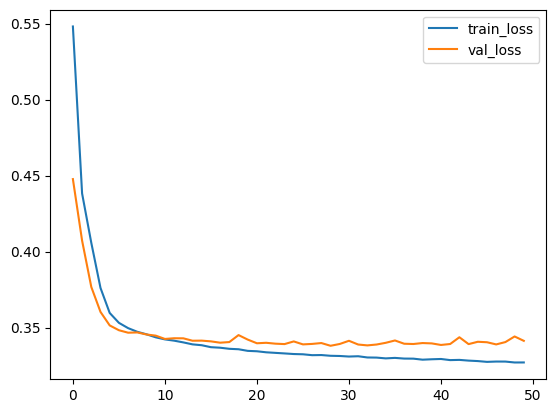

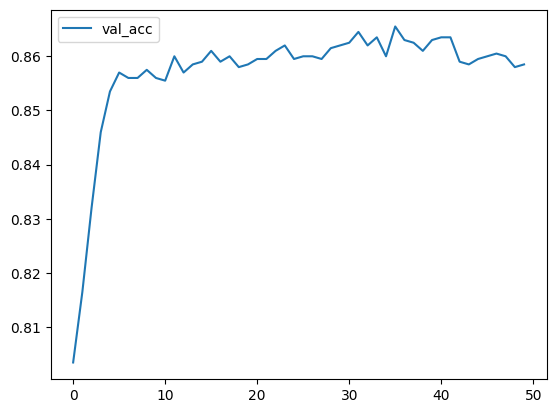

In [40]:
plt.plot(history['train_loss'], label='train_loss')
plt.plot(history['val_loss'], label='val_loss')
plt.legend(); plt.show()

plt.plot(history['val_acc'], label='val_acc')
plt.legend(); plt.show()

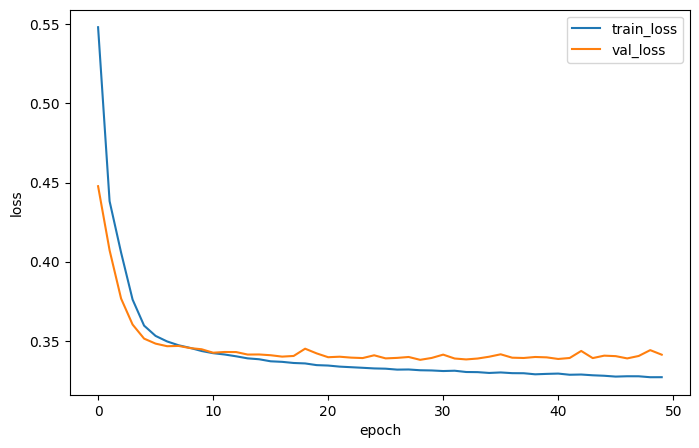

In [41]:
# seaborn version

import seaborn as sns
data = pd.DataFrame(history)

plt.figure(figsize=(8,5))
sns.lineplot(
    data=data,
    x=data.index,
    y="train_loss",
    label="train_loss"
)
sns.lineplot(
    data=data,
    x=data.index,
    y="val_loss",
    label="val_loss"
)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

## 4) Evaluate on test dataset

> **Side note** : in real life, we use a **test** dataset to measure model performance with real data. As we do not have such data, we will use the **validation** dataset instead. But this is a **BAD PRACTICE**.

Test Accuracy: 0.8585


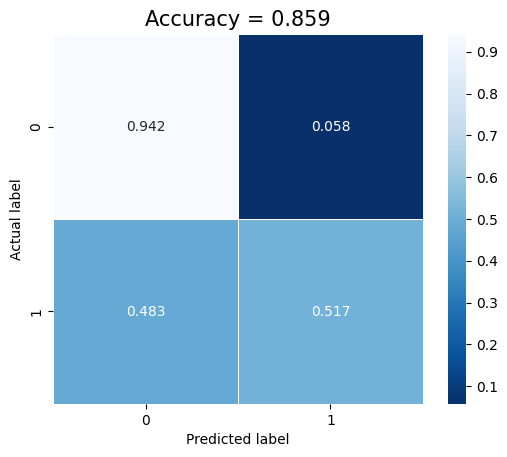

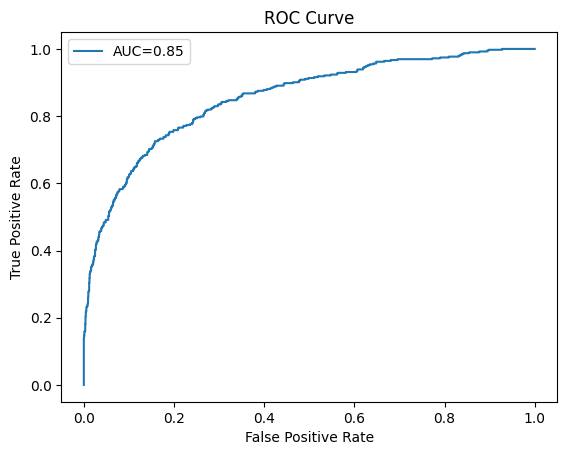

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix


test_loss, test_probs, _, test_trues = evaluate_classification(model, val_loader, criterion) # again, we use validation data only for lab convenience.

# Binary predictions
test_preds = (test_probs > 0.5).astype(int)

# Accuracy
accuracy = accuracy_score(test_trues, test_preds)
print("Test Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(test_trues, test_preds, normalize='true')
# plt.figure(figsize=(9, 9))
sns.heatmap(cm, annot=True, fmt=".3f", linewidths=.5, square=True, cmap='Blues_r')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.title(f"Accuracy = {accuracy:.3f}", size=15)
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(test_trues, test_probs)
plt.plot(fpr, tpr, label=f"AUC={auc(fpr,tpr):.2f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()



## 6) Save model

In [43]:
torch.save(
    {
        'model_state_dict': model.state_dict(),
        'input_dim': nb_input_features
    },
    'bank_net_pytorch.pt'
)

## 7) Load model

In [44]:
model_info = torch.load('bank_net_pytorch.pt')

In [45]:
# Create a new instance of the model and load the state dictionary
model = BankNet(model_info['input_dim'])
model.load_state_dict(model_info['model_state_dict'])
model.eval() # Set the model to evaluation mode

BankNet(
  (fc1): Linear(in_features=11, out_features=12, bias=True)
  (fc2): Linear(in_features=12, out_features=12, bias=True)
  (out): Linear(in_features=12, out_features=1, bias=True)
)